In [26]:
import pandas as pd

# Load your CSV file
df1 = pd.read_csv("processed_output.csv")  # Parallel run
df2 = pd.read_csv("processed_output_seq.csv")  # Sequential run

In [28]:
print(df1.shape)
print(df2.shape)

(74902, 8)
(74902, 8)


In [24]:
# Generate summary by worker
summary = (
    df1.groupby("processed_by_worker")
    .agg(
        total_rows_processed=("processed_by_worker", "count"),
        unique_files=("processed_file", "nunique")
    )
    .reset_index()
)

print(summary)

  processed_by_worker  total_rows_processed  unique_files
0      SpawnProcess-1                 19275           258
1      SpawnProcess-2                 15920           213
2      SpawnProcess-3                 20716           276
3      SpawnProcess-4                 18991           253


In [32]:
def get_metrics(df):
    ts = pd.to_datetime(df["load_timestamp"])
    duration = (ts.max() - ts.min()).total_seconds()
    workers = df["processed_by_worker"].unique().tolist()
    return duration, workers, len(df)


# Calculate metrics
t_par, par_workers, rows_par = get_metrics(df1)
t_seq, seq_workers, rows_seq = get_metrics(df2)

speedup = t_seq / t_par if t_par > 0 else 0
worker_count = len(par_workers)

print("=" * 70)
print(" PROCESSING PERFORMANCE SUMMARY ")
print("=" * 70)
print(f"Total Rows Processed : {rows_par:,}")
print(f"Sequential Processing Time      : {t_seq:.3f} seconds (1 process: {seq_workers[0]})")
print(f"Parallel Processing Time        : {t_par:.3f} seconds ({worker_count} workers)")
print("-" * 70)
print(
    f"Faster by {speedup:.2f}x using ProcessPoolExecutor with {worker_count} workers "
    f"({', '.join(par_workers)}) to process {rows_par:,} rows."
)
print("=" * 70)

 PROCESSING PERFORMANCE SUMMARY 
Total Rows Processed : 74,902
Sequential Processing Time      : 4.384 seconds (1 process: MainProcess)
Parallel Processing Time        : 1.660 seconds (4 workers)
----------------------------------------------------------------------
Faster by 2.64x using ProcessPoolExecutor with 4 workers (SpawnProcess-3, SpawnProcess-1, SpawnProcess-4, SpawnProcess-2) to process 74,902 rows.


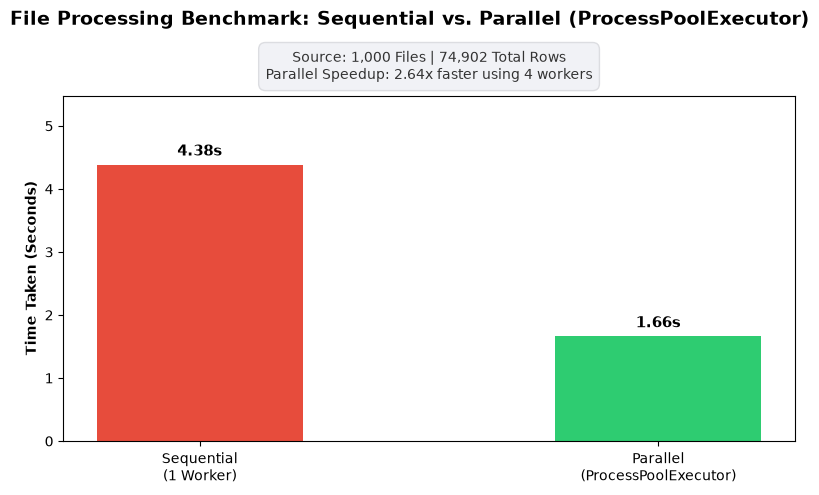

In [38]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. Source & Execution Details (Replace these with your variables)
# ---------------------------------------------------------------------------
total_files = 1000
total_rows = len(df1)  # e.g., 500,000 rows
num_workers = len(par_workers)  # e.g., 4 or 8 workers

# Execution Times (in seconds)
t_seq = t_seq
t_par = t_par
speedup = t_seq / t_par if t_par > 0 else 0

# ---------------------------------------------------------------------------
# 2. Plotting the Comparison Chart
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

methods = ["Sequential\n(1 Worker)", "Parallel\n(ProcessPoolExecutor)"]
times = [t_seq, t_par]
colors = ["#e74c3c", "#2ecc71"]

bars = ax.bar(methods, times, color=colors, width=0.45)

# Add value labels over each bar
for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + (max(times) * 0.02),
        f"{yval:.2f}s",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11,
    )

# Source Details Card as Subtitle/Title
title_text = f"File Processing Benchmark: Sequential vs. Parallel (ProcessPoolExecutor)"
subtitle_text = (
    f"Source: {total_files:,} Files | {total_rows:,} Total Rows\n"
    f"Parallel Speedup: {speedup:.2f}x faster using {num_workers} workers"
)

plt.suptitle(title_text, fontsize=14, fontweight="bold", y=0.98)
plt.title(
    subtitle_text,
    fontsize=10,
    color="#333333",
    pad=12,
    bbox=dict(
        boxstyle="round,pad=0.5", facecolor="#f1f2f6", edgecolor="#dcdde1"
    ),
)

plt.ylabel("Time Taken (Seconds)", fontweight="bold")
plt.ylim(0, max(times) * 1.25)
plt.tight_layout()

# Save & Show
plt.savefig("execution_time_comparison.png", dpi=300)
plt.show()